## Step 1: Load the dataset



In [1]:
import pandas as pd


In [2]:
#Load the dataset

data=pd.read_csv("sample_data.csv")
print(data)


        Name   Age    Salary  Join_Date Department
0        Pam  25.0   70200.0  1/15/2023         HR
1       Jane   NaN   65000.0   8/1/2022    Finance
2      Alice  22.0   71350.0  5/20/2021         HR
3        Bob  22.0       NaN  1/15/2023         IT
4        Pam  25.0   71250.0  1/15/2023         HR
5       Jade  40.0       NaN  1/15/2023    Finance
6     Joanne  25.0  120000.0  1/16/2023         IT
7        Kim  33.0   71568.0  8/30/2021         HR
8        Sam  40.0       NaN   9/5/2022         IT
9        Eli   NaN   80100.0   3/4/2022         HR
10       Joe  22.0   62000.0  10/9/2022    Finance
11      Anna  36.0   72456.0   4/6/2022         HR
12       Dan  43.0       NaN  1/15/2023         HR
13     Susan  46.0   66000.0   5/3/2022    Finance
14    Pamela   NaN   77421.0   4/2/2023         HR
15      Susy  41.0  126001.0   2/2/2023         IT
16      Ruth  30.0   72114.0   9/5/2022         HR
17       Dan  43.0       NaN   5/3/2022         HR
18    Joanne  25.0  125600.0  1

## Step-2: Identify Missing Values



In [3]:
print("\nMissing Values Count: ")
print(data.isnull().sum())




Missing Values Count: 
Name          0
Age           4
Salary        7
Join_Date     0
Department    0
dtype: int64


## Step-3: Handle Missing Values


In [4]:
data['Age'] = data['Age'].fillna(data['Age'].median())
data['Salary']=data['Salary'].fillna(data['Salary'].mean())
data= data.dropna(subset=['Join_Date'])

print(data)

        Name   Age         Salary  Join_Date Department
0        Pam  25.0   70200.000000  1/15/2023         HR
1       Jane  36.0   65000.000000   8/1/2022    Finance
2      Alice  22.0   71350.000000  5/20/2021         HR
3        Bob  22.0  132729.694444  1/15/2023         IT
4        Pam  25.0   71250.000000  1/15/2023         HR
5       Jade  40.0  132729.694444  1/15/2023    Finance
6     Joanne  25.0  120000.000000  1/16/2023         IT
7        Kim  33.0   71568.000000  8/30/2021         HR
8        Sam  40.0  132729.694444   9/5/2022         IT
9        Eli  36.0   80100.000000   3/4/2022         HR
10       Joe  22.0   62000.000000  10/9/2022    Finance
11      Anna  36.0   72456.000000   4/6/2022         HR
12       Dan  43.0  132729.694444  1/15/2023         HR
13     Susan  46.0   66000.000000   5/3/2022    Finance
14    Pamela  36.0   77421.000000   4/2/2023         HR
15      Susy  41.0  126001.000000   2/2/2023         IT
16      Ruth  30.0   72114.000000   9/5/2022    

## Step-4:Check and remove Duplicate rows


In [5]:
data = data.apply(lambda x: x.str.strip() if x.dtype=="object" else x)
print(data)

        Name   Age         Salary  Join_Date Department
0        Pam  25.0   70200.000000  1/15/2023         HR
1       Jane  36.0   65000.000000   8/1/2022    Finance
2      Alice  22.0   71350.000000  5/20/2021         HR
3        Bob  22.0  132729.694444  1/15/2023         IT
4        Pam  25.0   71250.000000  1/15/2023         HR
5       Jade  40.0  132729.694444  1/15/2023    Finance
6     Joanne  25.0  120000.000000  1/16/2023         IT
7        Kim  33.0   71568.000000  8/30/2021         HR
8        Sam  40.0  132729.694444   9/5/2022         IT
9        Eli  36.0   80100.000000   3/4/2022         HR
10       Joe  22.0   62000.000000  10/9/2022    Finance
11      Anna  36.0   72456.000000   4/6/2022         HR
12       Dan  43.0  132729.694444  1/15/2023         HR
13     Susan  46.0   66000.000000   5/3/2022    Finance
14    Pamela  36.0   77421.000000   4/2/2023         HR
15      Susy  41.0  126001.000000   2/2/2023         IT
16      Ruth  30.0   72114.000000   9/5/2022    

In [6]:
data= data.drop_duplicates(subset=['Name','Age'])
print(data)

        Name   Age         Salary  Join_Date Department
0        Pam  25.0   70200.000000  1/15/2023         HR
1       Jane  36.0   65000.000000   8/1/2022    Finance
2      Alice  22.0   71350.000000  5/20/2021         HR
3        Bob  22.0  132729.694444  1/15/2023         IT
5       Jade  40.0  132729.694444  1/15/2023    Finance
6     Joanne  25.0  120000.000000  1/16/2023         IT
7        Kim  33.0   71568.000000  8/30/2021         HR
8        Sam  40.0  132729.694444   9/5/2022         IT
9        Eli  36.0   80100.000000   3/4/2022         HR
10       Joe  22.0   62000.000000  10/9/2022    Finance
11      Anna  36.0   72456.000000   4/6/2022         HR
12       Dan  43.0  132729.694444  1/15/2023         HR
13     Susan  46.0   66000.000000   5/3/2022    Finance
14    Pamela  36.0   77421.000000   4/2/2023         HR
15      Susy  41.0  126001.000000   2/2/2023         IT
16      Ruth  30.0   72114.000000   9/5/2022         HR
19     Clark  44.0   76982.000000  1/28/2023    

In [7]:
print(data.duplicated().sum())

0


## Step-5: Handle Outliers


In [8]:
# Calculate IQR for Salary
Q1 = data['Salary'].quantile(0.25)
Q3 = data['Salary'].quantile(0.75)

IQR = Q3 - Q1

#Filtering Outliers
data = data[(data['Salary'] >= Q1 - 1.5 * IQR) & (data['Salary'] <= Q3+1.5* IQR)]
print(data)

        Name   Age         Salary  Join_Date Department
0        Pam  25.0   70200.000000  1/15/2023         HR
1       Jane  36.0   65000.000000   8/1/2022    Finance
2      Alice  22.0   71350.000000  5/20/2021         HR
3        Bob  22.0  132729.694444  1/15/2023         IT
5       Jade  40.0  132729.694444  1/15/2023    Finance
6     Joanne  25.0  120000.000000  1/16/2023         IT
7        Kim  33.0   71568.000000  8/30/2021         HR
8        Sam  40.0  132729.694444   9/5/2022         IT
9        Eli  36.0   80100.000000   3/4/2022         HR
10       Joe  22.0   62000.000000  10/9/2022    Finance
11      Anna  36.0   72456.000000   4/6/2022         HR
12       Dan  43.0  132729.694444  1/15/2023         HR
13     Susan  46.0   66000.000000   5/3/2022    Finance
14    Pamela  36.0   77421.000000   4/2/2023         HR
15      Susy  41.0  126001.000000   2/2/2023         IT
16      Ruth  30.0   72114.000000   9/5/2022         HR
19     Clark  44.0   76982.000000  1/28/2023    

## Step-6: Convert Data Types

In [9]:
data['Join_Date'] = pd.to_datetime(data['Join_Date'])
print(data)


        Name   Age         Salary  Join_Date Department
0        Pam  25.0   70200.000000 2023-01-15         HR
1       Jane  36.0   65000.000000 2022-08-01    Finance
2      Alice  22.0   71350.000000 2021-05-20         HR
3        Bob  22.0  132729.694444 2023-01-15         IT
5       Jade  40.0  132729.694444 2023-01-15    Finance
6     Joanne  25.0  120000.000000 2023-01-16         IT
7        Kim  33.0   71568.000000 2021-08-30         HR
8        Sam  40.0  132729.694444 2022-09-05         IT
9        Eli  36.0   80100.000000 2022-03-04         HR
10       Joe  22.0   62000.000000 2022-10-09    Finance
11      Anna  36.0   72456.000000 2022-04-06         HR
12       Dan  43.0  132729.694444 2023-01-15         HR
13     Susan  46.0   66000.000000 2022-05-03    Finance
14    Pamela  36.0   77421.000000 2023-04-02         HR
15      Susy  41.0  126001.000000 2023-02-02         IT
16      Ruth  30.0   72114.000000 2022-09-05         HR
19     Clark  44.0   76982.000000 2023-01-28    

## Step-7 Categorial Variables

In [12]:
data=pd.get_dummies(data,columns=['Department'],drop_first=True)
binary_columns=[col for col in data.columns if col.startswith('Department_')]
data[binary_columns]= data[binary_columns].astype(int)
print(data)

        Name   Age         Salary  Join_Date  Department_HR  Department_IT
0        Pam  25.0   70200.000000 2023-01-15              1              0
1       Jane  36.0   65000.000000 2022-08-01              0              0
2      Alice  22.0   71350.000000 2021-05-20              1              0
3        Bob  22.0  132729.694444 2023-01-15              0              1
5       Jade  40.0  132729.694444 2023-01-15              0              0
6     Joanne  25.0  120000.000000 2023-01-16              0              1
7        Kim  33.0   71568.000000 2021-08-30              1              0
8        Sam  40.0  132729.694444 2022-09-05              0              1
9        Eli  36.0   80100.000000 2022-03-04              1              0
10       Joe  22.0   62000.000000 2022-10-09              0              0
11      Anna  36.0   72456.000000 2022-04-06              1              0
12       Dan  43.0  132729.694444 2023-01-15              1              0
13     Susan  46.0   6600

## Save the dataset

In [13]:
data.to_csv("cleaned_data.csv",index=False)

## Visualization

In [15]:
import matplotlib.pyplot as plt
data=pd.read_csv("cleaned_data.csv")
print(data.head())

    Name   Age         Salary   Join_Date  Department_HR  Department_IT
0    Pam  25.0   70200.000000  2023-01-15              1              0
1   Jane  36.0   65000.000000  2022-08-01              0              0
2  Alice  22.0   71350.000000  2021-05-20              1              0
3    Bob  22.0  132729.694444  2023-01-15              0              1
4   Jade  40.0  132729.694444  2023-01-15              0              0


## Bar Chart for Departments

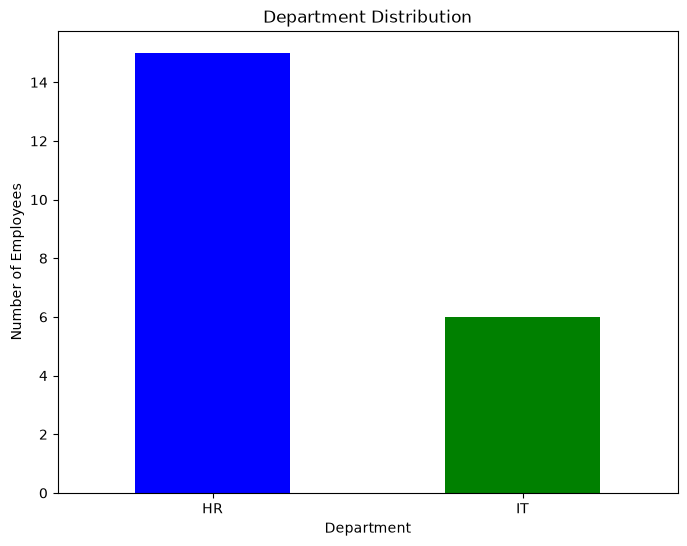

In [19]:
department_counts= data[['Department_HR','Department_IT']].sum()
department_counts.plot(kind='bar',color=['blue','green'],figsize=(8,6))
plt.title("Department Distribution")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(ticks=[0,1], labels=["HR","IT"], rotation=0)
plt.show()

## Histogram for Salaries

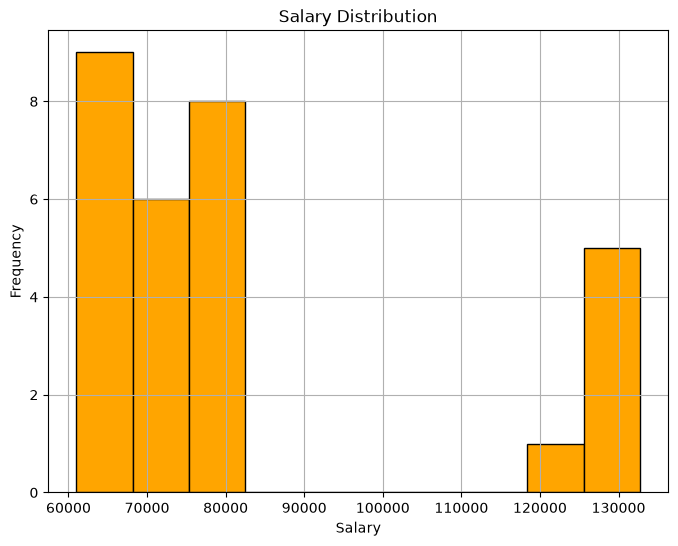

In [20]:
plt.figure(figsize=(8,6))
plt.hist(data['Salary'], bins=10, color='orange', edgecolor='black')
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

## Line plot for Age and Salary


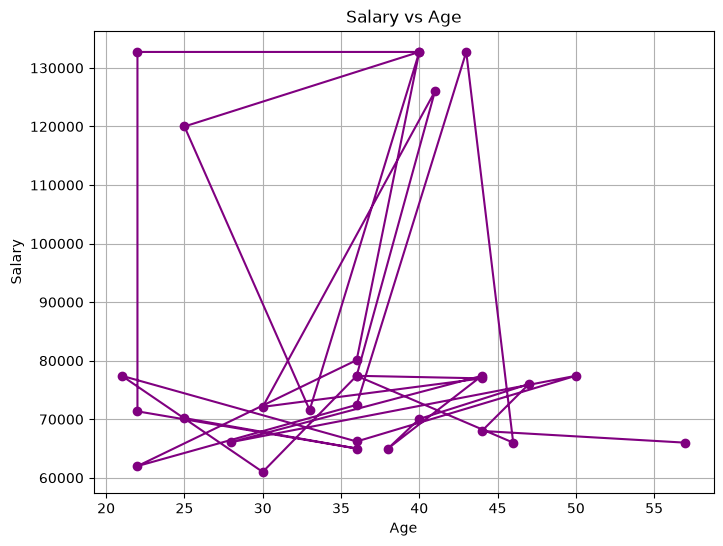

In [21]:
plt.figure(figsize=(8,6))
plt.plot(data['Age'], data['Salary'], marker='o', linestyle='-', color='purple')
plt.title("Salary vs Age")
plt.xlabel("Age")
plt.ylabel("Salary")
plt.grid(True)
plt.show()

## Scatter plot for Salary and Department

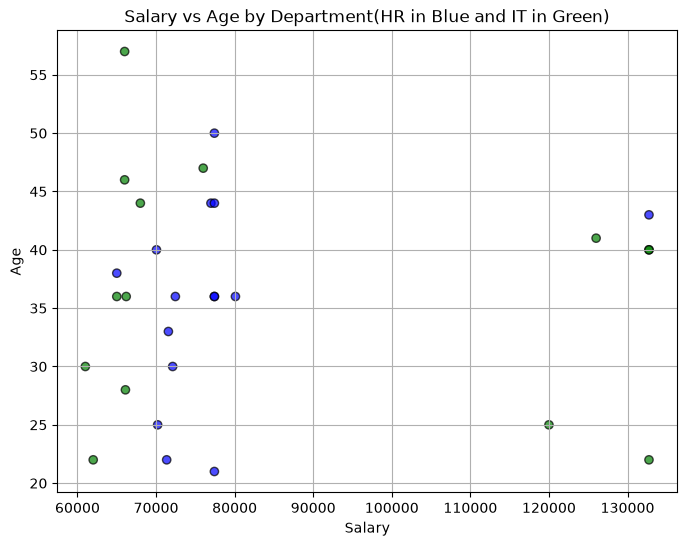

In [22]:
plt.figure(figsize=(8,6))
colors=['blue' if dept==1 else 'green' for dept in data['Department_HR']]
plt.scatter(data['Salary'], data['Age'], c=colors,alpha=0.7,edgecolor='black')
plt.title("Salary vs Age by Department(HR in Blue and IT in Green)")
plt.xlabel("Salary")
plt.ylabel("Age")
plt.grid(True)
plt.show()